<a href="https://colab.research.google.com/github/yahyaMohamadi/MCMC-for-MTEGR/blob/main/MCMC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# initiate


In [1]:
from scipy.integrate import quad
import numpy as np
import pandas as pd
from google.colab import drive
drive.mount('/content/drive')
!pip install getdist
from getdist import MCSamples
from getdist import plots
import matplotlib.pyplot as plt
from IPython.display import clear_output #this is for clearing priat and live plot part to dont have huge amount of output
#np.random.seed(42) #set if you want to reproduce the result
import requests #for conect telegram

Mounted at /content/drive
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 834.0/834.0 kB 12.7 MB/s eta 0:00:00


**MCMC FOR BAOs nad SN la**

# Definition

In [3]:
c = 299792.458  # speed of light in km/s
rd = 147.05      # sound horizon in Mpc

#dimension of curent parameters
dim = 4
parameters_name = ['alpha' ,'beta' ,'Omega_M' ,'H0']
#step_size = np.array([0.01,0.01,0.001,0.001]) #this stepsize is somehow have 30% acceptaion rate on BAO

LCDMparameters = np.array([0,0,0.315,73])

state = {0:"BAO"  ,
         1:"SNe"
         }

#definitions

def H(z , parameters = LCDMparameters):
  alpha, beta, Omega_M, H0 = parameters
  return H0 * ((1 + alpha) / (1 + alpha * (1 + z)**beta)) * np.sqrt(Omega_M * (1 + z)**3 + (1 - Omega_M))

def angular_diameter_distance(z, parameters = LCDMparameters):
  integral, _ = quad(lambda z_: 1 / H(z_, parameters), 0, z)
  return c / (1 + z) * integral

def volume_averaged_distance(z , parameters = LCDMparameters , rd = rd):
  DA = angular_diameter_distance(z, parameters)
  H_z = H(z, parameters)
  return (((1 + z)**2 * c * z / H_z * DA**2)**(1 / 3)) / rd


def luminosity_distance(z, parameters = LCDMparameters):
  return c*(1+z)*quad(lambda z_: 1/H(z_, parameters = parameters),0,z)[0]

def distance_modulus(z , parameters = LCDMparameters):

  return 5*np.log10(luminosity_distance(z , parameters = parameters))+25



#load and save

In [51]:
path_SNe = '/content/drive/MyDrive/chain_SNe_output.csv' #Chain path
path_BAO = '/content/drive/MyDrive/chain_BAO_output.csv'


def load_chain(state,
               parameters_name = parameters_name):
  if  state == "BAO":
    path = path_BAO
  elif state == "SNe":
    path = path_SNe
  data = pd.read_csv(path)
  return data[parameters_name].values.tolist() , data['chi2'].values.tolist()

#def save_chain(state , chain_sample , chain_chi2 , parameters_name = parameters_name ):
#  if  state == "BAO":
#    path = path_BAO
#  elif state == "SNe":
#    path = path_SNe
#  df = pd.DataFrame({**{"chi2": chain_chi2}, **{name: chain_sample[:, i] for i, name in enumerate(parameters_name)}})
#  df.to_csv(path, index=False)



def save_chain(state, chain_sample, chain_chi2 , n_step):
    if state == "BAO":
        path = path_BAO
    elif state == "SNe":
        path = path_SNe
    df_new = pd.DataFrame({
        "chi2": chain_chi2,
        **{name: chain_sample[:, i] for i, name in enumerate(parameters_name)}
    })
    if n_step+1 > len(chain_sample) :
      df_new = df_new.iloc[-n_step:]
      df_new.to_csv(path, mode='a', index=False, header=False)
      print("Chain increased.")
    else:
      df_new.to_csv(path, index=False)
      print("Chain saved.")



def get_data_SNe( path = '/content/drive/MyDrive/Pantheon+SH0ES.dat'):
  data = pd.read_csv(path , delim_whitespace=True)
  return np.stack((data['zCMB'].values ,data['MU_SH0ES'].values,data['MU_SH0ES_ERR_DIAG'].values) ,axis=1)


BAO_DESI_DR3 = {
    "BGS":   {"z": 0.295, "DV_over_rd": 7.942,  "error": 0.075},
    "LRG1":  {"z": 0.510, "DV_over_rd": 12.720, "error": 0.099},
    "LRG2":  {"z": 0.706, "DV_over_rd": 16.050, "error": 0.110},
    "LRG3":  {"z": 0.922, "DV_over_rd": 19.656, "error": 0.105},
    "LRG3+ELG1": {"z": 0.934, "DV_over_rd": 19.721, "error": 0.091},
    "ELG1":  {"z": 0.955, "DV_over_rd": 20.008, "error": 0.183},
    "ELG2":  {"z": 1.321, "DV_over_rd": 24.252, "error": 0.174},
    "QSO":   {"z": 1.484, "DV_over_rd": 26.055, "error": 0.398},
    "Lya":   {"z": 2.330, "DV_over_rd": 31.267, "error": 0.256},
}


def get_data_BAO(bao_dict : dict):
  return np.array([[v["z"], v["DV_over_rd"], v["error"]] for v in bao_dict.values()])


data_BAO = get_data_BAO(BAO_DESI_DR3)
data_SNe  = get_data_SNe()




/tmp/ipython-input-1564674037.py:44: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  data = pd.read_csv(path , delim_whitespace=True)


# MCMC

In [52]:
#the bond that parameter must be in that/ proposal will reject if is not in that bond
lower = np.array([-1, -5, 0.05, 55])   # lower limits-..>>> for this bond every  1000 step 1 of them out
upper = np.array([ 1,  5,  1, 85])  # upper limits

draw_diagram = False
counter_out = 0


def chi2(data ,state ,parameters = LCDMparameters):
  if state == "SNe":
    z  , observed_distance_modulus ,ERR = data.T
    MTEGR_distance_modulu = np.array([distance_modulus(z = z_ , parameters = parameters) for z_ in z])
    chi2 =  np.sum(((observed_distance_modulus-MTEGR_distance_modulu)/ERR)**2)
  elif state == "BAO":
      z, observed_volume_averaged_distance, ERR = data.T
      MTEGR_volume_averaged_distance = np.array([volume_averaged_distance(z = z_ , parameters = parameters) for z_ in z])
      chi2=  np.sum(((observed_volume_averaged_distance-MTEGR_volume_averaged_distance)/ERR)**2)
  elif state == "BAO+SNe":
      z_BAO, observed_volume_averaged_distance, ERR = data[0].T
      MTEGR_volume_averaged_distance = np.array([volume_averaged_distance(z = z_ , parameters = parameters) for z_ in z_BAO])
      chi2_BAO=  np.sum(((observed_volume_averaged_distance-MTEGR_volume_averaged_distance)/ERR)**2)
      z_SNe  , observed_distance_modulus ,ERR = data[1].T
      MTEGR_distance_modulu = np.array([distance_modulus(z = z_ , parameters = parameters) for z_ in z_SNe])
      chi2_SNe =  np.sum(((observed_distance_modulus-MTEGR_distance_modulu)/ERR)**2)
      chi2 = chi2_BAO/9 + chi2_SNe/1700
  return chi2



def in_bounds(params):
    return np.all(params >= lower) and np.all(params <= upper)


def MCMC_step(data ,
              state ,
              sample,
              sample_chi2,
              step_size):
  step_accepted = 0
  proposal_sample = np.random.normal(sample, step_size)
  if in_bounds(proposal_sample):
    proposal_chi2 = chi2(data, state,proposal_sample)
  else:
    proposal_chi2 = np.inf
    global counter_out
    counter_out+=1
  log_accept_prob  = -0.5 * (proposal_chi2- sample_chi2)
  if np.log(np.random.rand()) < log_accept_prob:
    current_sample = proposal_sample
    current_chi2  = proposal_chi2
    step_accepted = 1
  else:
    current_sample = sample
    current_chi2  = sample_chi2
    step_accepted = 0
  return current_sample , current_chi2 , step_accepted



def run_mcmc(data ,
             state,
             n_steps,
             step_size,
             parameters = LCDMparameters,
             report_state = 100,
             continue_fron_old_chian = False ,
             save_while_report =False):


  if continue_fron_old_chian:
      chain_samples , chain_chi2 = load_chain(state)
  else:
    #start chain from LambdaCDM point
    chain_samples = [parameters]
    chain_chi2= [chi2(data ,state, parameters)]
  for i in range(n_steps):
    step = MCMC_step(data,
                     state,
                     sample = chain_samples[-1] ,
                     sample_chi2 = chain_chi2[-1],
                     step_size = step_size)
    chain_samples.append(step[0])
    chain_chi2.append(step[1])
    if (i+2) % report_state == 0:
      live_report(chain_samples,chain_chi2 ,report_state =report_state ,draw_diagram = draw_diagram)
      curent_acceptation_rate = 0
      repot_tele((i/n_steps)*100)
      if save_while_report:
        save_chain(state,
                   np.array(chain_samples)[-report_state:] ,
                   np.array(chain_chi2)[-report_state:] ,
                   n_step = len(chain_samples) - report_state)

  return np.array(chain_samples) ,np.array(chain_chi2)



# reports

In [53]:

def live_report(chain_samples,
                chain_chi2 ,
                report_state ,
                draw_diagram = False):
    samples = list(zip(*chain_samples))
    clear_output(wait=True)
    if not draw_diagram:
      print("\n")
      print('step               : ', len(chain_chi2))
      print('acceptation rate % : ', (len(np.unique(chain_chi2[-report_state:]))/report_state)*100)
      print('chi2               : {:.3f}'.format(  np.average(chain_chi2[-report_state:])))
      print('alpha              : {:.3f}'.format(  np.average(samples[0][-report_state:])))
      print('beta               : {:.2f}'.format(  np.average(samples[1][-report_state:])))
      print('Omega_m%           : {:.2f}'.format(  np.average(samples[2][-report_state:])*100))
      print('H_0                : {:.2f}'.format(  np.average(samples[3][-report_state:])))
      print('outer oints:       : ' ,counter_out)

    if draw_diagram:
      plt_number = 4+2
      for i in [1,2,3,4]:
        plt.subplot(plt_number, 1, i)
        plt.plot(samples[i-1], marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
        plt.ylabel(parameters_name[i-1])

      plt.subplot(plt_number, 1, 5)
      plt.plot(chain_chi2, marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
      plt.ylabel("chi")
      plt.subplot(plt_number, 1, 6)

      acceptation_rate = [(len(np.unique(chain_chi2[i:i+report_state])) / report_state)*100 for i in range(0, len(chain_chi2), report_state)]
      plt.plot(acceptation_rate, marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
      plt.ylabel("acc")
      plt.tight_layout()
      plt.show()

#try to connect with my tele bot toke is <8470305957:AAFX1TnfuFsBT56SqpRWFExVQy8PSnR8UDQ> my id <1039455774>

def repot_tele(progress):
  url = 'https://api.telegram.org/bot8470305957:AAFX1TnfuFsBT56SqpRWFExVQy8PSnR8UDQ/sendMessage?chat_id=1039455774&text='
  url+='The%20progress%20is%20'+str(round(progress,2))
  response = requests.get(url)
  return response



In [ ]:
#in average for each data point take 1.6 min for one million step
#each 10^6 steps take about 30 megabyte size
mcmc = run_mcmc(data=data_BAO ,
                state="BAO",
                n_steps=6*1000*1000,
                step_size=np.array([1.44209936e-01, 1.04608905e-03, 4.59450094e-05, 2.03832221e-03]),
                parameters = np.array([ 0   ,  0   ,  .3 , 70.   ]),
                report_state = 100000,
                continue_fron_old_chian = False ,
                save_while_report =True)



step               :  200000
acceptation rate % :  63.037
chi2               : 9.310
alpha              : 0.629
beta               : 0.10
Omega_m%           : 30.57
H_0                : 69.83
outer oints:       :  13100
Chain increased.


# autocorrelation

In [27]:
def autocorrelation(chain, lag):
  autocorrelation = []
  n = len(chain)
  mean = np.mean(chain)
  var = np.var(chain)
  for i in range(lag):
    cov = np.sum((chain[:n-i] - mean) * (chain[i:] - mean)) / (n - i)
    autocorrelation.append(cov / var)
  return np.array(autocorrelation)

#Sokal windowing

def autocorrelation_SW(chain):
  autocorrelation = [1]
  n = len(chain)
  mean = np.mean(chain)
  var = np.var(chain)
  i = 1
  while (1+2*np.sum(autocorrelation))*5 > i :
    cov = np.sum((chain[:n-i] - mean) * (chain[i:] - mean)) / (n - i)
    autocorrelation.append(cov / var)
    i+=1
  return np.array(autocorrelation)

In [ ]:
burn_in =1000
alpha_chain = mcmc[0][burn_in:,0]
beta_chain = mcmc[0][burn_in:,1]
Omega_M_chain = mcmc[0][burn_in:,2]
H0_chain = mcmc[0][burn_in:,3]


alpha_autocorrelation = autocorrelation_SW(chain=alpha_chain)



plt.plot(alpha_autocorrelation , marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
plt.title("alpha_chain autocorrelation")
plt.xlabel("Step")
plt.show()

beta_autocorrelation = autocorrelation_SW(chain=beta_chain)

plt.plot(beta_autocorrelation , marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
plt.title("beta_autocorrelation")
plt.xlabel("Step")
plt.show()

Omega_M_autocorrelation = autocorrelation_SW(chain=Omega_M_chain)


plt.plot(Omega_M_autocorrelation , marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
plt.title("Omega_M_autocorrelation")
plt.xlabel("Step")
plt.show()

H0_autocorrelation = autocorrelation_SW(chain=H0_chain)

plt.plot(H0_autocorrelation , marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
plt.title("H0_autocorrelation")
plt.xlabel("Step")
plt.show()

#Integrated autocorrelation time
alpha_autocorrelation_IAT = 1+2*np.sum(alpha_autocorrelation)
beta_autocorrelation_IAT =  1+2*np.sum(beta_autocorrelation)
Omega_M_autocorrelation_IAT =1+2*np.sum(Omega_M_autocorrelation)
H0_autocorrelation_IAT =  1+2*np.sum(H0_autocorrelation)

print("alpha_autocorrelation_IAT: " , alpha_autocorrelation_IAT)
print("beta_autocorrelation_IAT: " , beta_autocorrelation_IAT)
print("Omega_M_autocorrelation_IAT: " , Omega_M_autocorrelation_IAT)
print("H0_autocorrelation_IAT: " , H0_autocorrelation_IAT)

NameError: name 'mcmc' is not defined

# Plot and Output

In [31]:
#load chain from drive if its exist
chain_SNe  , chi2_SNe = np.array(load_chain("SNe")[0]) , np.array(load_chain("SNe")[1])
chain_BAO  , chi2_BAO = np.array(load_chain("BAO")[0]) , np.array(load_chain("BAO")[1])
#chain_BAO_SNe = np.array(chain_BAO_SNe)

In [ ]:
#chain from runtime
chain_SNe  , chi2_SNe = mcmc[0] , mcmc[1]
chain_BAO  , chi2_BAO = mcmc[0] , mcmc[1]
#chain_BAO_SNe = np.array(chain_BAO_SNe)

In [ ]:
def main_chain_report(chain_samples ,chain_chi2):
  print("best point: " , chain_samples[np.argmin(chain_chi2)] , np.min(chain_chi2))
  print("total acceptation rate: " , len(np.unique(chain_chi2))/len(chain_chi2)*100)
  print("mean of chain" , np.mean(chain_samples,axis=0))
  print("error" , np.std(chain_samples,axis=0))
#main_chain_report(chain_SNe,chi2_SNe)
main_chain_report(chain_BAO,chi2_BAO)

best point:  [ 0.95272997  0.09414246  0.33535119 68.58753437] 5.206165706010942
total acceptation rate:  20.612261904761905
mean of chain [ 0.14256514 -0.22575527  0.33188416 68.79243627]
error [0.33614787 0.37039763 0.03022762 0.53475341]


In [ ]:
for i in range(3):
  main_chain_report(np.split(chain_BAO[:-1] , 3)[i],np.split(chi2_BAO[:-1],3)[i])

In [ ]:
main_chain_report(chain_BAO[2000000:],chi2_BAO[2000000:])

best point:  [ 0.95272997  0.09414246  0.33535119 68.58753437] 5.206165706010942
total acceptation rate:  29.219181818181816
mean of chain [3.57769440e-01 1.33905150e-02 3.47803996e-01 6.84346238e+01]
error [0.33155326 0.33526753 0.03411681 0.41435516]


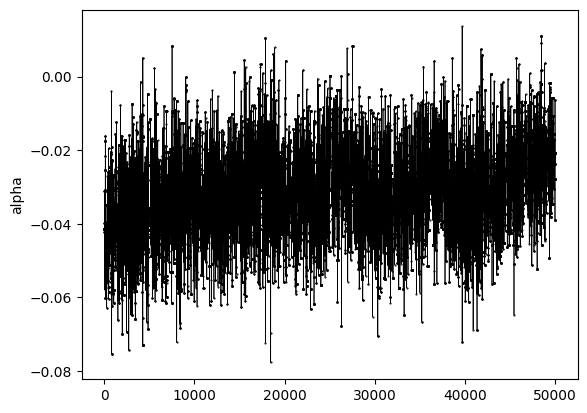

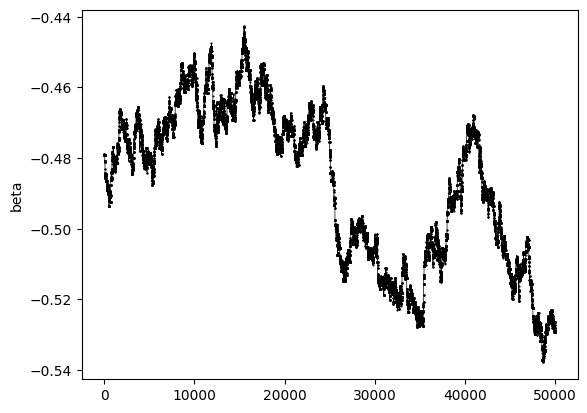

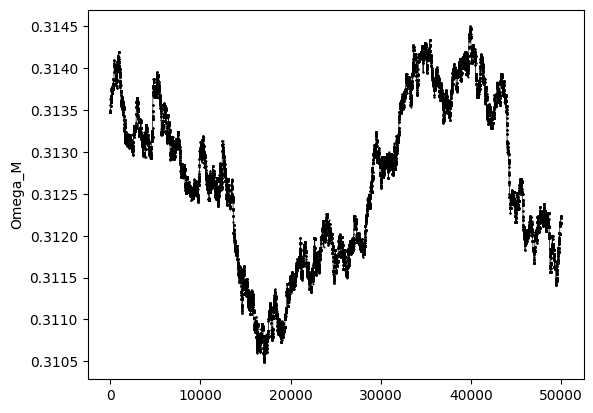

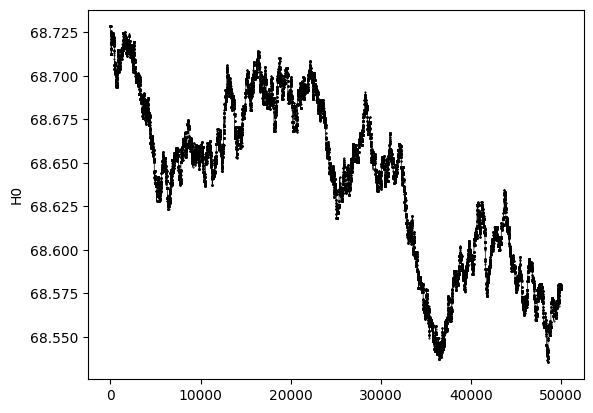

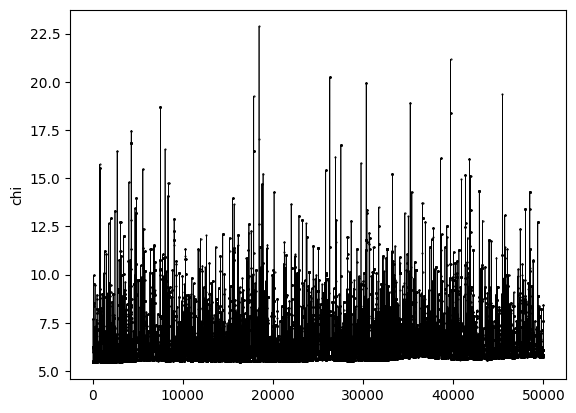

In [ ]:
def chain_visual(chain_samples,
                chain_chi2 ):
      samples = chain_samples.T
      for i in range(len(parameters_name)):
        plt.plot(samples[i], marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
        plt.ylabel(parameters_name[i])
        plt.show()
      plt.plot(chain_chi2, marker='.' ,ms = 1,linewidth = '0.5',linestyle='-',color = 'black')
      plt.ylabel("chi")
      plt.show()

chain_visual(chain_BAO[4000000:4040000],
                chi2_BAO[4000000:4040000])

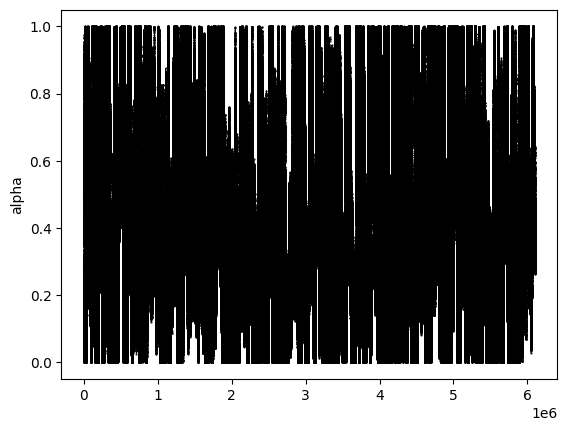

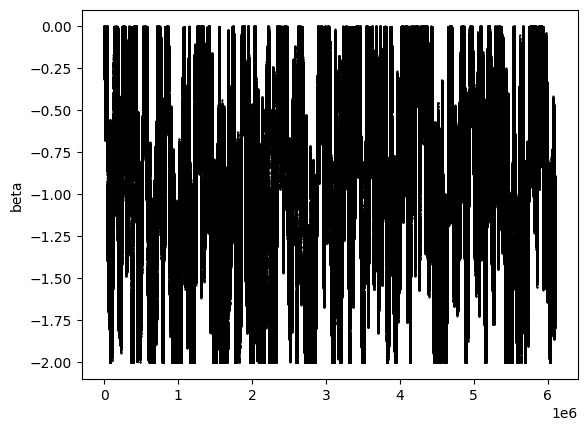

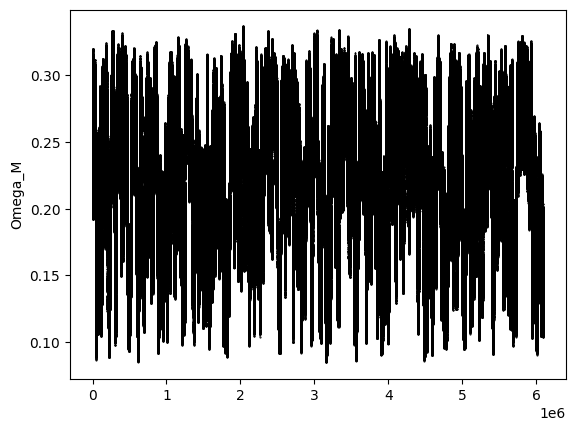

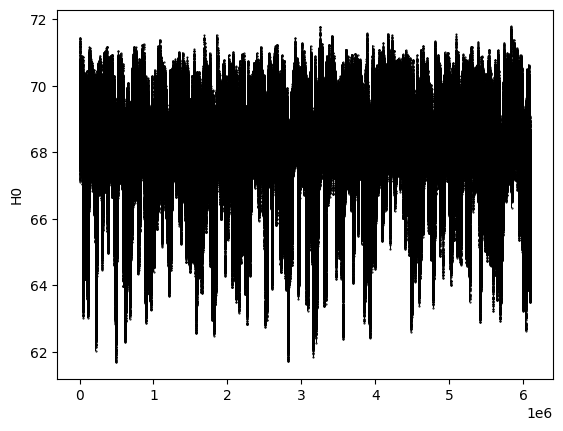

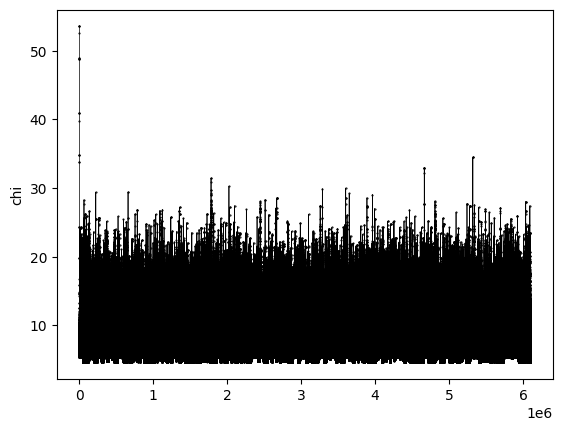

In [ ]:
chain_visual(chain_BAO,
                chi2_BAO)

In [ ]:
burn_in = 100000
samples = chain_BAO[burn_in:]
parameter_labels=[r'\alpha', r'\beta' ,  r'\Omega_m','H_0']
samples_obj = MCSamples(samples=samples,
                        names = parameters_name,
                        labels =parameter_labels)

Removed no burn in


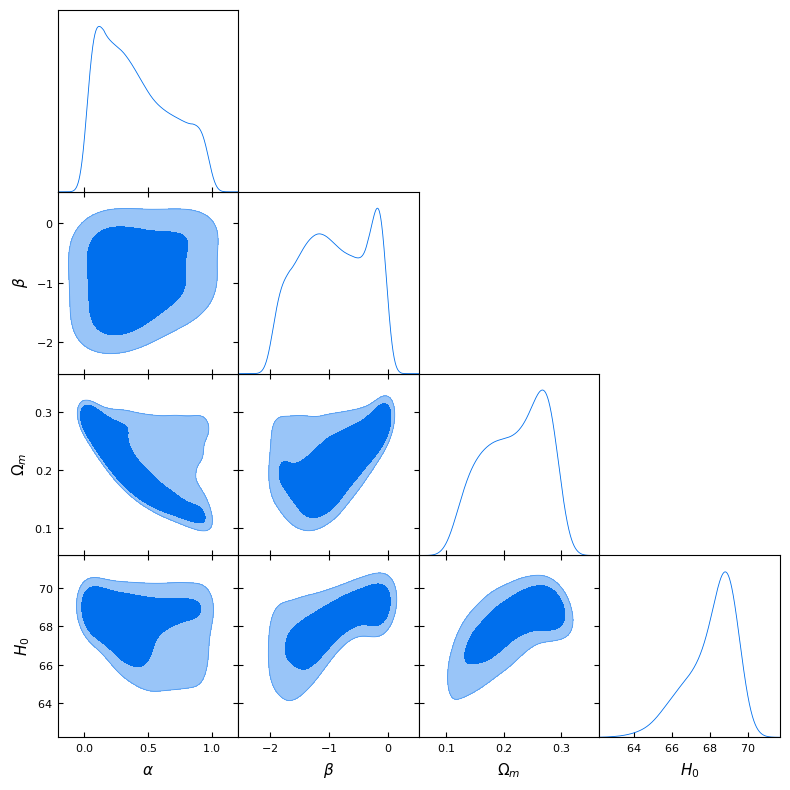

In [ ]:
g = plots.get_subplot_plotter()
g.triangle_plot(samples_obj, filled=True)
plt.savefig("triangle_plot.png")
plt.show()

In [ ]:
#triangle plot for  joint data
g = plots.get_subplot_plotter()
g.triangle_plot([samples1, samples2,samples3],
                filled=True,
                legend_labels=["SNe", "BAO" , "SNe+BAO"],
                contour_colors=['blue', 'red',"green"])

plt.savefig("triangle_plot.png")

Removed no burn in
Removed no burn in
Removed no burn in


# Tuning and Running
* this part need more attention



component-wise scheme----> this make prameter update one-by-one and good for seeing the acceptaiton rate for all parameter

> Add blockquote





In [ ]:
def MCMC_step_wise(data ,
              state ,
              sample,
              sample_chi2,
              step_size):
  step_accepted = np.zeros(len(sample), dtype=int)
  proposal  = np.random.normal(sample, step_size)
  proposal_sample_new = sample
  for i in range(len(sample)):
    if lower[i] < proposal[i] and  proposal[i] <upper[i]:
      proposal_sample_new[i] = proposal[i]
      proposal_chi2 = chi2(data, state, proposal_sample_new)
    else:
      proposal_chi2 = np.inf
      global counter_out
      counter_out+=1
    log_accept_prob  = -0.5 * (proposal_chi2- sample_chi2)
    if np.log(np.random.rand()) < log_accept_prob:
      step_accepted[i] = 1
      sample_chi2 = proposal_chi2
    else:
      proposal_sample_new[i] = sample[i]
  return proposal_sample_new , proposal_chi2 , step_accepted


def run_mcmc_wise(data ,
             state,
             n_steps,
             step_size,
             parameters = LCDMparameters,
             report_state = 100,
             continue_fron_old_chian = False ,
             save_while_report =False):

  curent_accepted_rate = np.zeros(len(LCDMparameters), dtype=int)
  accepted_rate =[]
  if continue_fron_old_chian:
      chain_samples , chain_chi2 = load_chain(state)
  else:
    #start chain from LambdaCDM point
    chain_samples = [parameters]
    chain_chi2= [chi2(data ,state, parameters)]
  for i in range(n_steps):
    step = MCMC_step_wise(data,
                     state,
                     sample = chain_samples[-1] ,
                     sample_chi2 = chain_chi2[-1],
                     step_size = step_size)
    chain_samples.append(step[0])
    chain_chi2.append(step[1])
    curent_accepted_rate +=step[2]
    if (i+2) % report_state == 0:
      #live_report(chain_samples,chain_chi2 ,report_state =report_state ,draw_diagram = draw_diagram)
      #repot_tele((i/n_steps)*100)
      accepted_rate.append((curent_accepted_rate/report_state)*100)
      curent_accepted_rate = np.zeros(len(LCDMparameters), dtype=int)
      if save_while_report:
        save_chain(state, np.array(chain_samples) ,np.array(chain_chi2) ) #make path for save

  return np.array(chain_samples) ,np.array(chain_chi2) , np.mean(accepted_rate, axis=0)

In [ ]:
lower_acceptation = np.array([35,35,35,35])
upper_acceptation =np.array([45,45,45,45])
start_parameter = LCDMparameters
start_step_size = np.array([0.01 ,0.001 ,0.0001 ,0.01])
# this is find form this tuning [1.44209936e-01 1.04608905e-03 4.59450094e-05 2.03832221e-03]
while True:

  print("start_step_size:   ",start_step_size)

  mcmc = run_mcmc_wise(data=data_BAO ,
                state="BAO",
                n_steps=1000,
                step_size=start_step_size,
                parameters = start_parameter,
                report_state = 1000,
                continue_fron_old_chian = False ,
                save_while_report =False)
  acceptation = mcmc[2]

  if np.all(acceptation > lower_acceptation) & np.all(acceptation < upper_acceptation):
    break
  for i in range(len(LCDMparameters)):
    if acceptation[i] < lower_acceptation[i]:
      start_step_size[i] = start_step_size[i]*0.9
    if acceptation[i] > upper_acceptation[i]:
      start_step_size[i] = start_step_size[i]*1.1
  start_parameter= mcmc[0][-1]

  print("acceptation:       ",acceptation)
  #print("start_parameter:   ",start_parameter)
  print("---------------")


start_step_size:    [0.01   0.001  0.0001 0.01  ]
acceptation:        [77.  58.1 51.1 45.6]
---------------
start_step_size:    [0.011   0.0011  0.00011 0.011  ]
acceptation:        [68.6 52.  44.2 43. ]
---------------
start_step_size:    [0.0121  0.00121 0.00011 0.011  ]
acceptation:        [62.9 53.2 45.5 41.8]
---------------
start_step_size:    [0.01331  0.001331 0.000121 0.011   ]
acceptation:        [72.2 56.1 48.7 42.4]
---------------
start_step_size:    [0.014641  0.0014641 0.0001331 0.011    ]
acceptation:        [86.4 56.5 48.2 43.5]
---------------
start_step_size:    [0.0161051  0.00161051 0.00014641 0.011     ]
acceptation:        [65.  48.8 42.  36.4]
---------------
start_step_size:    [0.01771561 0.00177156 0.00014641 0.011     ]
acceptation:        [49.6 44.6 36.2 30.6]
---------------
start_step_size:    [0.01948717 0.00177156 0.00014641 0.0099    ]
acceptation:        [51.3 39.3 32.6 29.7]
---------------
start_step_size:    [0.02143589 0.00177156 0.00013177 0.0089